In [ ]:
# Feature  Importance: sensitivity analysis for each element using gradients from the final ElemNet model
import torch
import torch.nn as nn

class ElemNetBest(nn.Module):
    def __init__(self):
        super().__init__()
        hidden_dims = [2048, 128, 512, 256, 128]   # <--- Best architecture found in part 1
        dropout = 0.217
        act_fn = nn.LeakyReLU

        layers = []
        dims = [118] + hidden_dims
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.BatchNorm1d(dims[i + 1]))
            layers.append(act_fn())
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(1)


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ElemNetBest().to(device)
model.load_state_dict(torch.load("elemnet_final_trainval.pt", map_location=device))
model.eval()

print("Model loaded successfully ✅")


Model loaded successfully ✅


In [5]:
from torchsummary import summary
summary(model, (118,))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 2048]         243,712
       BatchNorm1d-2                 [-1, 2048]           4,096
         LeakyReLU-3                 [-1, 2048]               0
           Dropout-4                 [-1, 2048]               0
            Linear-5                  [-1, 128]         262,272
       BatchNorm1d-6                  [-1, 128]             256
         LeakyReLU-7                  [-1, 128]               0
           Dropout-8                  [-1, 128]               0
            Linear-9                  [-1, 512]          66,048
      BatchNorm1d-10                  [-1, 512]           1,024
        LeakyReLU-11                  [-1, 512]               0
          Dropout-12                  [-1, 512]               0
           Linear-13                  [-1, 256]         131,328
      BatchNorm1d-14                  [

In [6]:
for name, param in model.named_parameters():
    if "weight" in name:
        print(f"{name}: mean={param.data.abs().mean():.4f}, max={param.data.abs().max():.4f}")


network.0.weight: mean=0.1638, max=1.5156
network.1.weight: mean=0.5683, max=0.9801
network.4.weight: mean=0.1782, max=1.0936
network.5.weight: mean=0.5815, max=0.7796
network.8.weight: mean=0.1856, max=1.0538
network.9.weight: mean=0.6231, max=1.0537
network.12.weight: mean=0.1868, max=1.0568
network.13.weight: mean=0.5805, max=0.8294
network.16.weight: mean=0.2046, max=0.9041
network.17.weight: mean=0.6297, max=0.9695
network.20.weight: mean=0.1905, max=0.3487


In [ ]:
#data load and split
import pandas as pd
import numpy as np

df = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv", on_bad_lines="skip", engine="python")
df["composition_vector"] = df["composition_vector"].apply(eval)

X = np.vstack(df["composition_vector"].values).astype(np.float32)
y = df["is_topological"].astype(np.float32).values


from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, stratify=y_trainval, random_state=42
) 


In [ ]:
import numpy as np

def permutation_importance(model, X, y, metric):
    base_preds = model(torch.tensor(X).float().to(device)).detach().cpu().numpy()
    base_score = metric(y, base_preds)

    importances = []
    for i in range(X.shape[1]):
        X_perm = X.copy()
        np.random.shuffle(X_perm[:, i])   # permute one feature
        perm_preds = model(torch.tensor(X_perm).float().to(device)).detach().cpu().numpy()
        perm_score = metric(y, perm_preds)
        importances.append(base_score - perm_score)  # drop in performance

    return np.array(importances)

from sklearn.metrics import roc_auc_score
importances = permutation_importance(model, X_test, y_test, roc_auc_score)

# Ranking elements by importance
from periodictable import elements
element_symbols = [e.symbol for e in list(elements) if e.number <= 118]

feature_ranking = sorted(zip(element_symbols, importances), key=lambda x: x[1], reverse=True)
feature_ranking[:100]


[('O', 0.10342904290429056),
 ('S', 0.020758105222286938),
 ('F', 0.0184911667637353),
 ('Cl', 0.015058823529411902),
 ('H', 0.013425936711318198),
 ('Cu', 0.01305222286934582),
 ('Co', 0.012352941176470567),
 ('Ni', 0.010634828188701206),
 ('P', 0.009569598136284219),
 ('Se', 0.00866627839254508),
 ('I', 0.008504950495049513),
 ('N', 0.008003300330032936),
 ('C', 0.007877693651718198),
 ('Pd', 0.007415453310036901),
 ('K', 0.007288099398175207),
 ('Si', 0.007193360512521951),
 ('Ag', 0.007136284216657129),
 ('Ti', 0.007050863909920602),
 ('Yb', 0.00625956125024274),
 ('Fe', 0.00609376820034957),
 ('Al', 0.005662589788390626),
 ('Ge', 0.005610949330226989),
 ('Na', 0.0055098039215686345),
 ('Pt', 0.005408464375849409),
 ('Cs', 0.005017084061347266),
 ('Ir', 0.004880799844690364),
 ('B', 0.00487594641817124),
 ('Nb', 0.004771306542418974),
 ('In', 0.004759464181712247),
 ('As', 0.004599301106581244),
 ('Sn', 0.004263638128518932),
 ('Br', 0.004257619879635022),
 ('Tl', 0.004209279751504

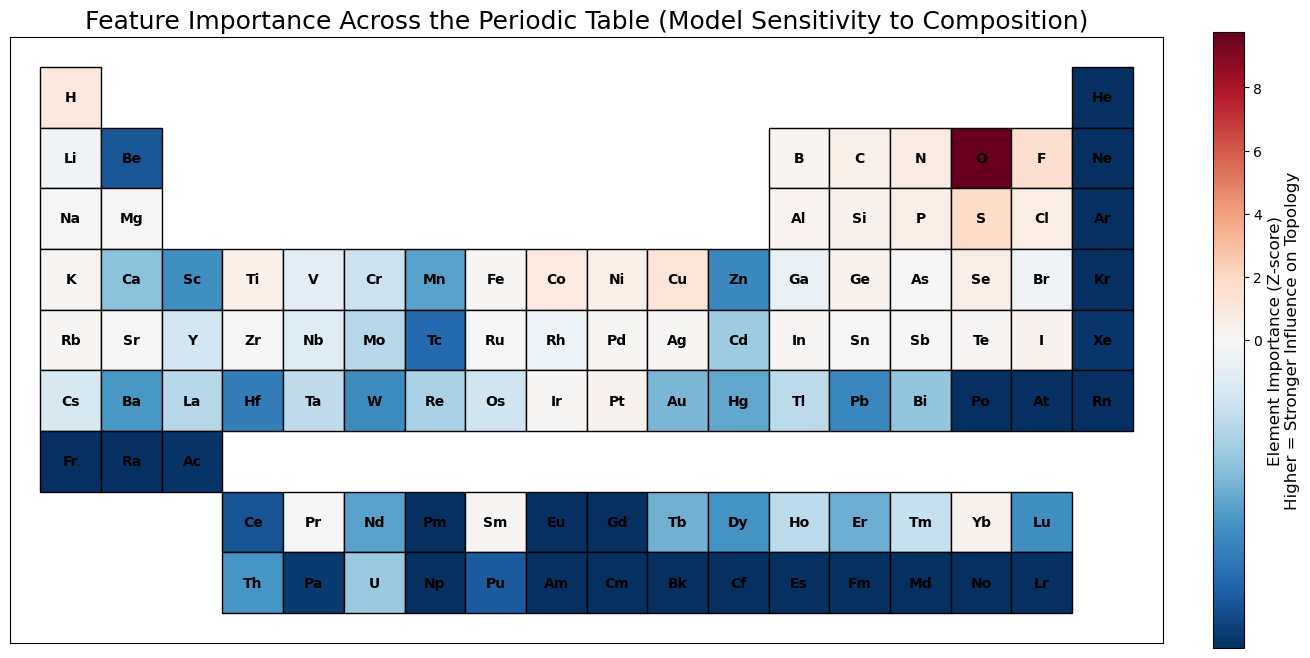

In [ ]:
#visualize on a periodic table
import numpy as np


importance_dict = dict(feature_ranking)   # from your permutation importance result

pt_layout = {
    "H": (0,0),  "He": (0,17),
    "Li": (1,0), "Be": (1,1),                                       "B": (1,12), "C": (1,13), "N": (1,14), "O": (1,15), "F": (1,16), "Ne": (1,17),
    "Na": (2,0), "Mg": (2,1),                                       "Al": (2,12),"Si": (2,13),"P": (2,14),"S": (2,15),"Cl": (2,16),"Ar": (2,17),
    "K": (3,0),  "Ca": (3,1),"Sc": (3,2),"Ti": (3,3),"V": (3,4),"Cr": (3,5),"Mn": (3,6),"Fe": (3,7),"Co": (3,8),"Ni": (3,9),"Cu": (3,10),"Zn": (3,11),
                                         "Ga": (3,12),"Ge": (3,13),"As": (3,14),"Se": (3,15),"Br": (3,16),"Kr": (3,17),
    "Rb": (4,0),"Sr": (4,1),"Y": (4,2),"Zr": (4,3),"Nb": (4,4),"Mo": (4,5),"Tc": (4,6),"Ru": (4,7),"Rh": (4,8),"Pd": (4,9),"Ag": (4,10),"Cd": (4,11),
                                         "In": (4,12),"Sn": (4,13),"Sb": (4,14),"Te": (4,15),"I": (4,16),"Xe": (4,17),
    "Cs": (5,0),"Ba": (5,1),                                                     "La": (5,2),
    "Hf": (5,3),"Ta": (5,4),"W": (5,5),"Re": (5,6),"Os": (5,7),"Ir": (5,8),"Pt": (5,9),"Au": (5,10),"Hg": (5,11),
                                         "Tl": (5,12),"Pb": (5,13),"Bi": (5,14),"Po": (5,15),"At": (5,16),"Rn": (5,17),
    "Fr": (6,0),"Ra": (6,1),                                                     "Ac": (6,2),
    # Lanthanides
    "Ce": (7,3),"Pr": (7,4),"Nd": (7,5),"Pm": (7,6),"Sm": (7,7),"Eu": (7,8),"Gd": (7,9),"Tb": (7,10),"Dy": (7,11),
    "Ho": (7,12),"Er": (7,13),"Tm": (7,14),"Yb": (7,15),"Lu": (7,16),
    # Actinides
    "Th": (8,3),"Pa": (8,4),"U": (8,5),"Np": (8,6),"Pu": (8,7),"Am": (8,8),"Cm": (8,9),"Bk": (8,10),"Cf": (8,11),
    "Es": (8,12),"Fm": (8,13),"Md": (8,14),"No": (8,15),"Lr": (8,16),
}
values = np.array(list(importance_dict.values()))
mean, std = np.mean(values), np.std(values)
z_scores = {el: (val-mean)/std for el,val in importance_dict.items()}
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize

fig, ax = plt.subplots(figsize=(16,8))

norm = TwoSlopeNorm(vcenter=0, vmin=min(z_scores.values()), vmax=max(z_scores.values()))
cmap = plt.cm.RdBu_r  # Blue = topological, Red = trivial shift

for el, (r,c) in pt_layout.items():
    value = z_scores.get(el, 0)
    color = cmap(norm(value))
    rect = plt.Rectangle((c, r), 1, 1, facecolor=color, edgecolor="black")
    ax.add_patch(rect)
    ax.text(c+0.5, r+0.5, el, ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_xlim(-0.5, 18.5)
ax.set_ylim(9.5, -0.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Element Importance (Z-score)\nHigher = Stronger Influence on Topology", fontsize=12)

plt.title("Feature Importance Across the Periodic Table (Model Sensitivity to Composition)", fontsize=18)
plt.show()


In [27]:
# Your existing ranking:
# feature_ranking = sorted(zip(element_symbols, importances), ... )
# But we also want a dict for fast lookup:
importance_dict = {el: imp for el, imp in zip(element_symbols, importances)}


In [28]:
periodic_table_positions = {
    # row, col positions (1-indexed)
    "H": (1,1),  "He": (1,18),
    "Li": (2,1), "Be": (2,2),                                      "B": (2,13), "C": (2,14), "N": (2,15), "O": (2,16), "F": (2,17), "Ne": (2,18),
    "Na": (3,1), "Mg": (3,2),                                      "Al": (3,13), "Si": (3,14), "P": (3,15), "S": (3,16), "Cl": (3,17), "Ar": (3,18),
    "K": (4,1),  "Ca": (4,2), "Sc": (4,3), "Ti": (4,4), "V": (4,5), "Cr": (4,6), "Mn": (4,7), "Fe": (4,8), "Co": (4,9), "Ni": (4,10), "Cu": (4,11), "Zn": (4,12),
                        "Ga": (4,13), "Ge": (4,14), "As": (4,15), "Se": (4,16), "Br": (4,17), "Kr": (4,18),
    "Rb": (5,1), "Sr": (5,2), "Y": (5,3), "Zr": (5,4), "Nb": (5,5), "Mo": (5,6), "Tc": (5,7), "Ru": (5,8), "Rh": (5,9), "Pd": (5,10), "Ag": (5,11), "Cd": (5,12),
                        "In": (5,13), "Sn": (5,14), "Sb": (5,15), "Te": (5,16), "I": (5,17),  "Xe": (5,18),
    "Cs": (6,1), "Ba": (6,2),
    "La": (9,4), "Ce": (9,5), "Pr": (9,6), "Nd": (9,7), "Pm": (9,8), "Sm": (9,9), "Eu": (9,10), "Gd": (9,11), "Tb": (9,12), 
    "Dy": (9,13), "Ho": (9,14), "Er": (9,15), "Tm": (9,16), "Yb": (9,17), "Lu": (9,18),
    "Hf": (6,4), "Ta": (6,5), "W": (6,6), "Re": (6,7), "Os": (6,8), "Ir": (6,9), "Pt": (6,10), "Au": (6,11), "Hg": (6,12),
                        "Tl": (6,13), "Pb": (6,14), "Bi": (6,15), "Po": (6,16), "At": (6,17), "Rn": (6,18),
    "Fr": (7,1), "Ra": (7,2),
    "Ac": (10,4),"Th": (10,5),"Pa": (10,6),"U": (10,7),"Np": (10,8),"Pu": (10,9),"Am": (10,10),"Cm": (10,11),"Bk": (10,12),"Cf": (10,13),"Es": (10,14),"Fm": (10,15),"Md": (10,16),"No": (10,17),"Lr": (10,18),
}


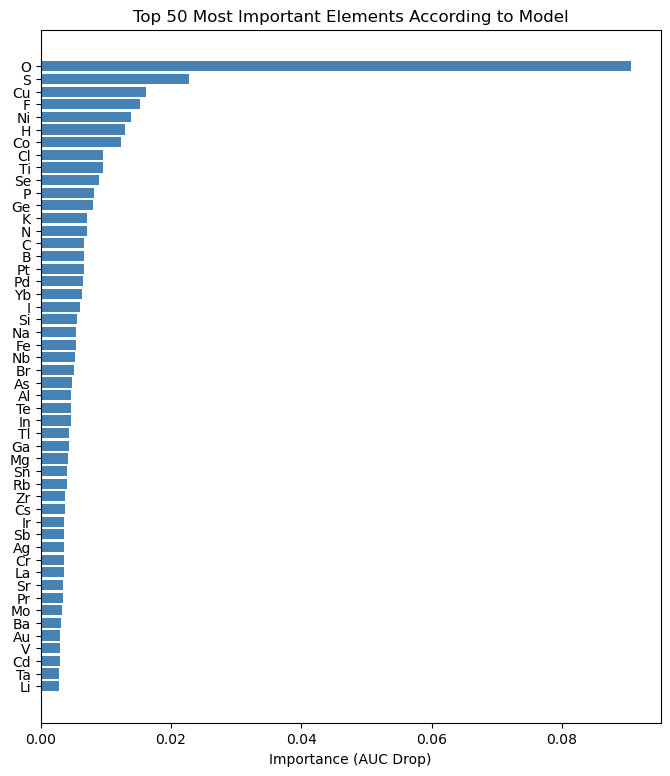

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df_imp = pd.DataFrame(feature_ranking[:50], columns=["Element","Importance"])

plt.figure(figsize=(8,9))
plt.barh(df_imp["Element"], df_imp["Importance"], color="steelblue")
plt.xlabel("Importance (AUC Drop)")
plt.gca().invert_yaxis()
plt.title("Top 50 Most Important Elements According to Model")
plt.show()


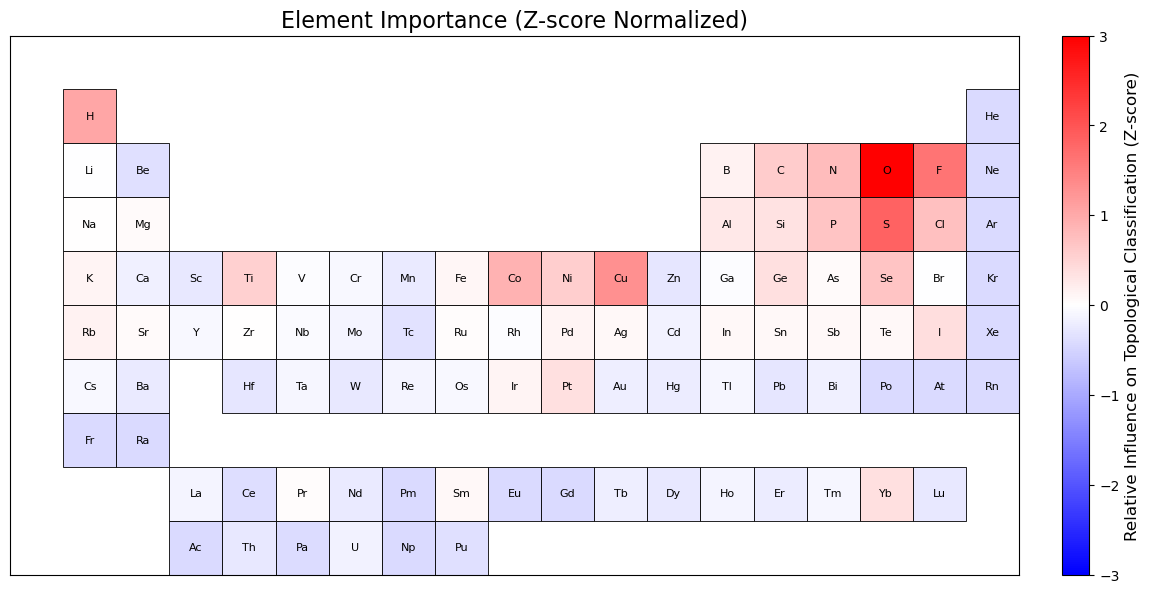

In [ ]:
#z-score normalized importances 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

 
colors = [
    (0, 0, 1),   # Blue
    (1, 1, 1),   # White
    (1, 0, 0)    # Red
]
strong_bwr = LinearSegmentedColormap.from_list("strong_bwr", colors, N=256)

#  z-score normalized importances
elements, values = zip(*feature_ranking)
values = np.array(values)
z_scores = (values - np.mean(values)) / np.std(values)
importance = dict(zip(elements, z_scores))

# ==== Periodic Table Plot (same as before) ====
fig, ax = plt.subplots(figsize=(14,7))

norm = TwoSlopeNorm(vcenter=0, vmin=-3, vmax=3)

for el, (r, c) in element_positions.items():
    val = importance.get(el, 0)
    color = strong_bwr(norm(val))  # ← use new colormap here
    rect = plt.Rectangle((c, r), 1, 1, facecolor=color, edgecolor="black", linewidth=0.6)
    ax.add_patch(rect)
    ax.text(c + 0.5, r + 0.5, el, ha="center", va="center", fontsize=8)

ax.set_xlim(0, 19)
ax.set_ylim(10, 0)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Element Importance (Z-score Normalized)", fontsize=16)


sm = plt.cm.ScalarMappable(cmap=strong_bwr, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Relative Influence on Topological Classification (Z-score)", fontsize=12)

plt.show()


In [ ]:
import torch
import torch.onnx._internal.exporter 

model = ElemNetBest().to(device)
model.load_state_dict(torch.load("elemnet_final_trainval.pt", map_location=device))
model.eval()

dummy = torch.randn(1, 118).to(device)

torch.onnx.export(
    model,
    dummy,
    "elemnet_best.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
    do_constant_folding=True
)

print("✅ Exported model to elemnet_best.onnx successfully!")


W1105 03:24:39.817000 35360 site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W1105 03:24:40.363000 35360 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `ElemNetBest([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ElemNetBest([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).
Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\AhmedFahmy\anaconda3\Lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\AhmedFahmy\anaconda3\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\AhmedFahmy\anaconda3\Lib\site-packages\onnxscript\version_converter\__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\AhmedFahmy\anaconda3\Lib\site-pac

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 5 of general pattern rewrite rules.
✅ Exported model to elemnet_best.onnx successfully!


In [26]:
import onnx

model_onnx = onnx.load("elemnet_best.onnx")
onnx.checker.check_model(model_onnx)
print("✅ ONNX model is valid!")


✅ ONNX model is valid!


In [5]:
import torch
import torch.nn as nn

class ElemNetBest(nn.Module):
    def __init__(self):
        super().__init__()
        hidden_dims = [2048, 128, 512, 256, 128]
        dropout = 0.217
        act_fn = nn.LeakyReLU

        layers = []
        dims = [118] + hidden_dims
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(act_fn())
            layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(hidden_dims[-1], 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(1)


In [ ]:
#  t-SNE 
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ElemNetBest().to(device)
model.load_state_dict(torch.load("elemnet_final_trainval.pt", map_location=device))
model.eval()

df = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv")
df["composition_vector"] = df["composition_vector"].apply(eval)

X = np.vstack(df["composition_vector"].values).astype(np.float32)
y = df["is_topological"].astype(int).values

X_tensor = torch.tensor(X).to(device)


In [ ]:
def extract_embeddings(model, X_tensor):
    # Remove final layer = everything except last Linear
    feature_extractor = nn.Sequential(*list(model.network[:-1]))  
    feature_extractor.to(device).eval()

    with torch.no_grad():
        embeddings = feature_extractor(X_tensor).cpu().numpy()

    return embeddings


In [8]:
import numpy as np

embeddings = extract_embeddings(model, torch.tensor(X, dtype=torch.float32).to(device))
print(embeddings.shape)   # Expected: (N_samples, 128)


(22245, 128)


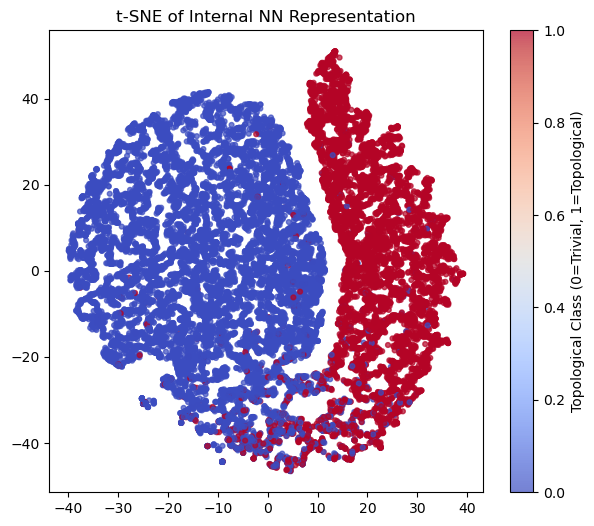

In [9]:
from openTSNE import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=35, learning_rate=200, random_state=42)
emb_2d = tsne.fit(embeddings)

plt.figure(figsize=(7,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=y, cmap="coolwarm", alpha=0.7, s=12)
plt.colorbar(label="Topological Class (0=Trivial, 1=Topological)")
plt.title("t-SNE of Internal NN Representation")
plt.show()


In [11]:
def get_latent_representation(model, X):
    """
    Returns the feature embedding from the last hidden layer (before final classification).
    """
    with torch.no_grad():
        # model.network[:-1] removes the last Linear layer
        features = model.network[:-1](X)
    return features


In [14]:
import torch
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ElemNetBest().to(device)
model.load_state_dict(torch.load("elemnet_final_trainval.pt", map_location=device))
model.eval()

# Load labeled dataset
df_labelled = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv")
X = np.vstack(df_labelled["composition_vector"].apply(eval).values).astype(np.float32)
y = df_labelled["is_topological"].astype(int).values

# Convert to tensor
X_torch = torch.tensor(X).to(device)

# Extract embeddings
with torch.no_grad():
    embeddings = get_latent_representation(model, X_torch).cpu().numpy()


print("Embeddings shape:", embeddings.shape)





Embeddings shape: (22245, 128)


In [15]:
import torch
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ElemNetBest().to(device)
model.load_state_dict(torch.load("elemnet_final_trainval.pt", map_location=device))
model.eval()

# Load labeled dataset
df_labelled = pd.read_csv("materiae_All_Labelled_withSOC_with_Composition_Vectors.csv")
X = np.vstack(df_labelled["composition_vector"].apply(eval).values).astype(np.float32)
y = df_labelled["is_topological"].astype(int).values

# Convert to tensor
X_torch = torch.tensor(X).to(device)

# Extract embeddings
with torch.no_grad():
    embeddings = get_latent_representation(model, X_torch).cpu().numpy()


In [ ]:
#trying higher perplexity
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, learning_rate=200, random_state=42)
emb_2d = tsne.fit_transform(embeddings) 


In [ ]:
# Location of the predicted candidate materials in the Topogivity first paper
df_new = pd.read_csv("topogivity_found_materials_without_intersections.csv")

X_new = np.vstack(df_new["composition_vector"].apply(eval).values).astype(np.float32)
X_new_torch = torch.tensor(X_new).to(device)

with torch.no_grad():
    embeddings_new = get_latent_representation(model, X_new_torch).cpu().numpy()

from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=1).fit(embeddings)
distances, indices = nbrs.kneighbors(embeddings_new)
emb_new_2d = emb_2d[indices[:,0]]


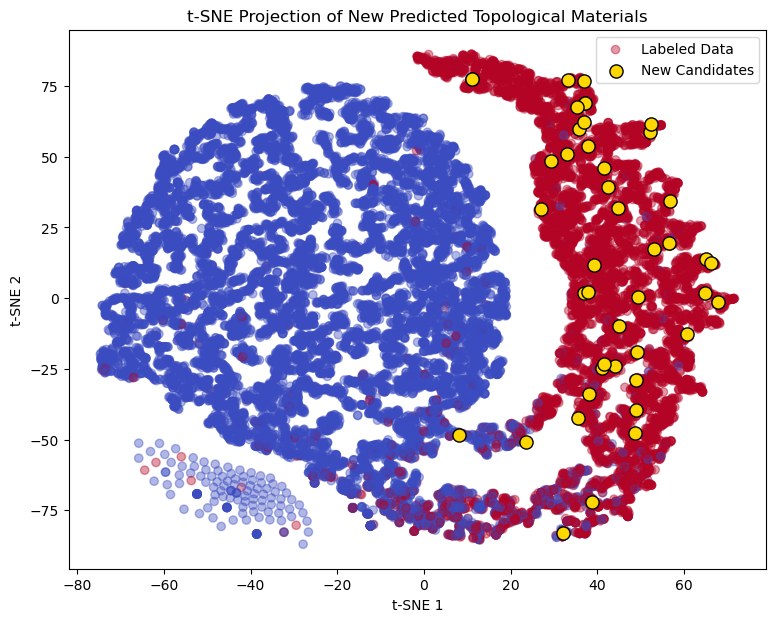

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=y, cmap="coolwarm", alpha=0.4, label="Labeled Data")
plt.scatter(emb_new_2d[:,0], emb_new_2d[:,1], c="gold", edgecolor="black", s=90, label="New Candidates")

plt.title("t-SNE Projection of New Predicted Topological Materials")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.show()


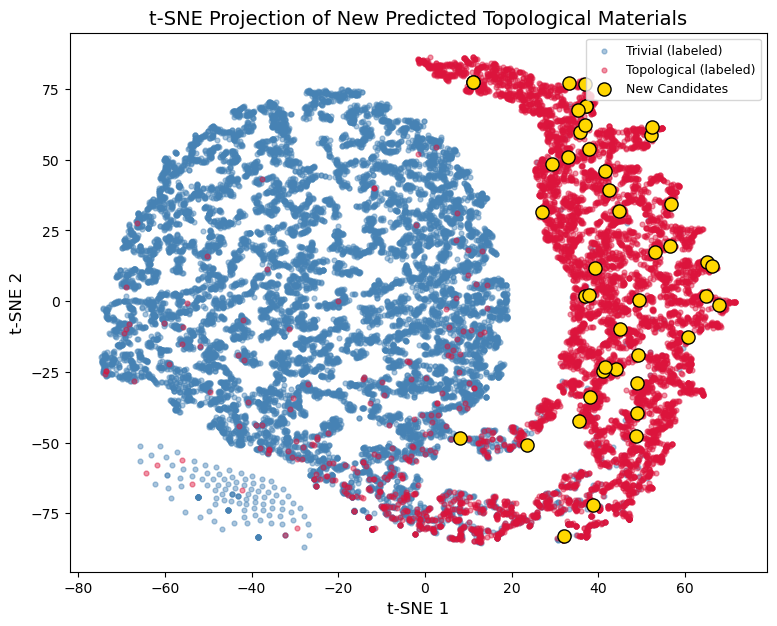

In [ ]:
# Detailed plot with labeled classes and new candidates (same as above wither different plot style)
import matplotlib.pyplot as plt
import numpy as np

# Separate labeled dataset into two groups
labeled_trivial = emb_2d[y == 0]
labeled_topological = emb_2d[y == 1]

plt.figure(figsize=(9,7))

# Trivial (0) = blue
plt.scatter(labeled_trivial[:,0], labeled_trivial[:,1],
            c="steelblue", alpha=0.45, s=12, label="Trivial (labeled)")

# Topological (1) = red
plt.scatter(labeled_topological[:,0], labeled_topological[:,1],
            c="crimson", alpha=0.45, s=12, label="Topological (labeled)")

# New predicted topological candidates = yellow
plt.scatter(emb_new_2d[:,0], emb_new_2d[:,1],
            c="gold", edgecolor="black", s=90, label="New Candidates")

plt.title("t-SNE Projection of New Predicted Topological Materials", fontsize=14)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)

# Legend location + smaller text size
plt.legend(loc='upper right', fontsize=9, frameon=True)

plt.show()


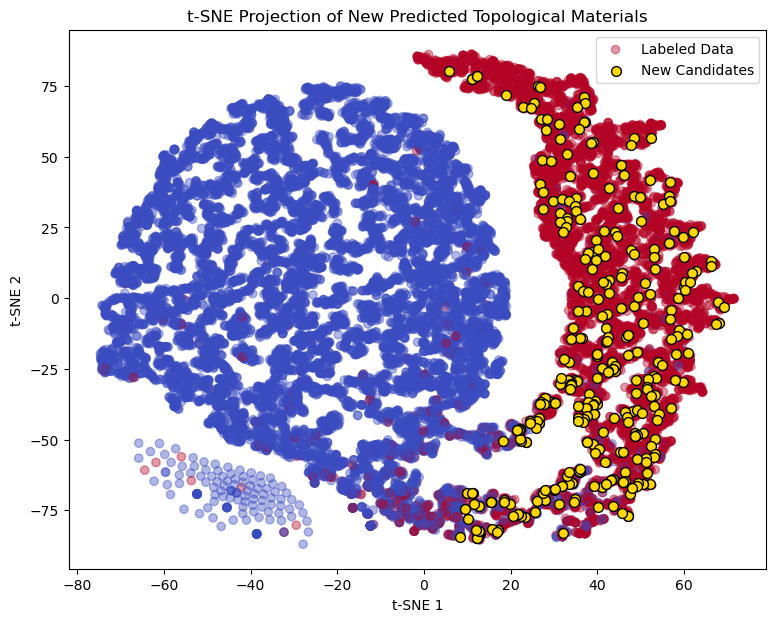

In [ ]:
# Location of the predicted candidate materials in the ElemNet final model
df_new = pd.read_csv("predicted_topological_materials.csv")

X_new = np.vstack(df_new["composition_vector"].apply(eval).values).astype(np.float32)
X_new_torch = torch.tensor(X_new).to(device)

with torch.no_grad():
    embeddings_new = get_latent_representation(model, X_new_torch).cpu().numpy()

from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=1).fit(embeddings)
distances, indices = nbrs.kneighbors(embeddings_new)
emb_new_2d = emb_2d[indices[:,0]]



import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=y, cmap="coolwarm", alpha=0.4, label="Labeled Data")
plt.scatter(emb_new_2d[:,0], emb_new_2d[:,1], c="gold", edgecolor="black", s=50, label="New Candidates")

plt.title("t-SNE Projection of New Predicted Topological Materials")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.show()
